In [1]:
# Basic
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso

# Metrics
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv("train.csv")

# Display data
df.head()
# Basic info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


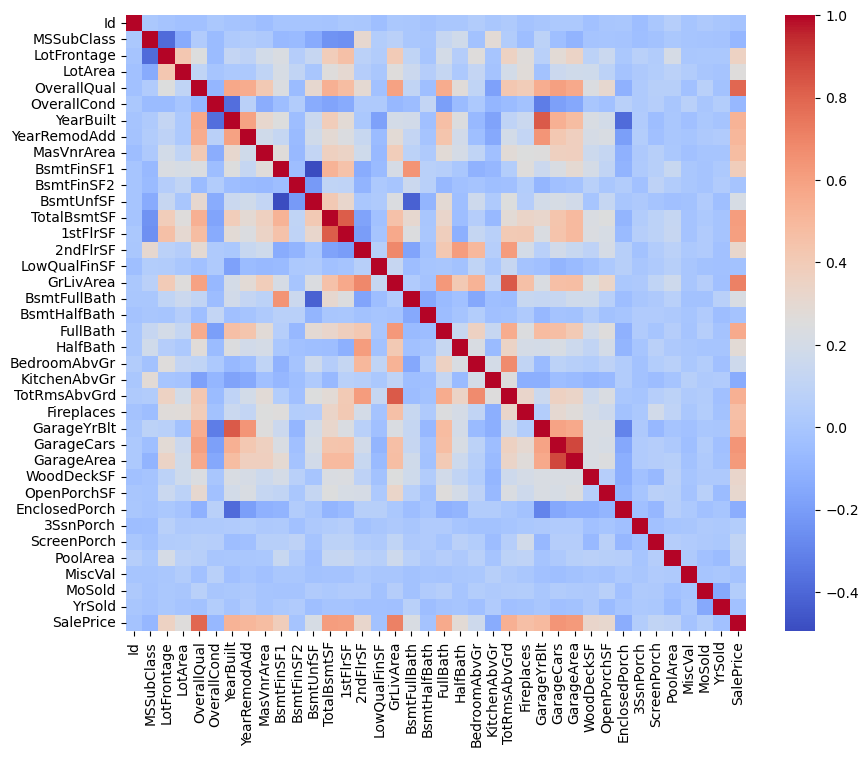

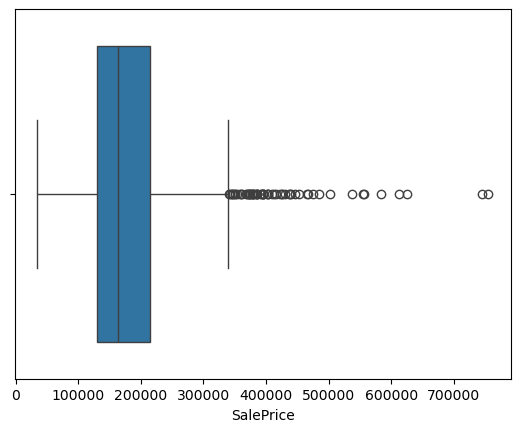

In [3]:
# Check missing values
df.isnull().sum().sort_values(ascending=False).head(10)

# Correlation heatmap (only numeric)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

# Outlier visualization
sns.boxplot(x=df['SalePrice'])
plt.show()

In [4]:
# Selecting important numeric features
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
target = 'SalePrice'

X = df[features]
y = df[target]

In [5]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [9]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression MSE:", mse)
print("Linear Regression R2:", r2)

Linear Regression MSE: 2806426667.2471337
Linear Regression R2: 0.6341189942329308


In [10]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge R2: 0.6339101620205354


In [11]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Lasso R2: 0.6341184812106226


In [12]:
# Create classification target
y_class = (df['SalePrice'] > df['SalePrice'].median()).astype(int)

X = df[features]
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [13]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_class = log_model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred_class))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_class))

Accuracy: 0.8595890410958904
Confusion Matrix:
 [[133  28]
 [ 13 118]]


In [15]:
print("Linear R2:", r2_score(y_test, lr.predict(X_test)))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Linear R2: -139661394727.139
Ridge R2: -139637073136.50668
Lasso R2: -139661317586.46042


In [16]:
# Use only one feature for visualization
X_vis = df[['GrLivArea']].values
y_vis = df['SalePrice'].values

# Handle missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_vis = imputer.fit_transform(X_vis)

# Train-test split
from sklearn.model_selection import train_test_split
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=42
)

# Train Linear Regression
from sklearn.linear_model import LinearRegression
model_vis = LinearRegression()
model_vis.fit(X_train_vis, y_train_vis)

# Predictions
y_pred_vis = model_vis.predict(X_test_vis)

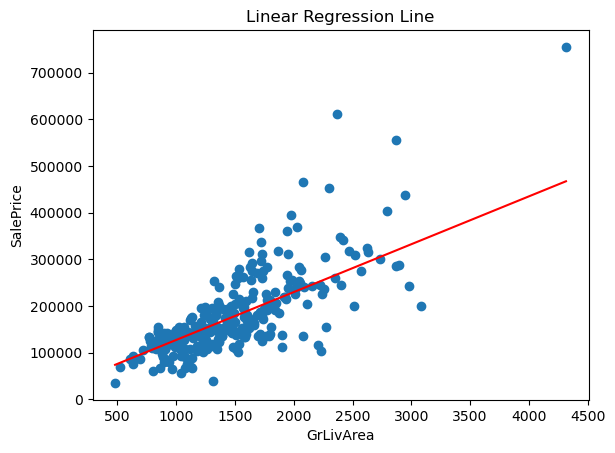

In [18]:
# Scatter plot of actual data
plt.scatter(X_test_vis, y_test_vis)

# Sort values for proper line plotting
sorted_idx = X_test_vis[:, 0].argsort()
X_sorted = X_test_vis[sorted_idx]
y_sorted_pred = y_pred_vis[sorted_idx]

# Plot regression line
plt.plot(X_sorted, y_sorted_pred, color='red')

# Labels
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Linear Regression Line")

plt.show()

In [19]:
# Use one feature
X_vis = df[['GrLivArea']].values
y_class = (df['SalePrice'] > df['SalePrice'].median()).astype(int)

# Handle missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_vis = imputer.fit_transform(X_vis)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_vis, y_class, test_size=0.2, random_state=42
)

# Train Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Create smooth X range
import numpy as np
X_range = np.linspace(X_vis.min(), X_vis.max(), 300).reshape(-1, 1)

# Predict probabilities
y_prob = model.predict_proba(X_range)[:, 1]

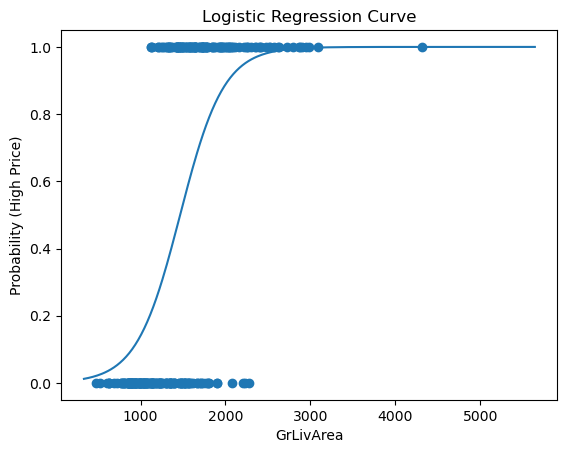

In [21]:
import matplotlib.pyplot as plt

# Scatter actual data
plt.scatter(X_test, y_test)

# Plot sigmoid curve
plt.plot(X_range, y_prob)

plt.xlabel("GrLivArea")
plt.ylabel("Probability (High Price)")
plt.title("Logistic Regression Curve")

plt.show()